# Welcome to seaborn

### Why Seaborn?

- provides a layer of abstraction hence simpler to use
- better aesthetics
- more graphs included

### Seaborn Roadmap

Types of Functions

- Figure Level
- Axis Level

Main Classification

- Relational Plot
- Distribution Plot
- Categorical Plot
- Regression Plot
- Matrix Plot
- Multiplots

https://seaborn.pydata.org/api.html

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Importing built-in datasets

In [3]:
tips = sns.load_dataset('tips')
tips.head() 
#guess how pandas .head() worked without importing the library, cause under the hood it was imported by seaborn. 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. Relational Plot

- to see the statistical relation between 2 or more variables.
- Bivariate Analysis

Plots under this section

- scatterplot
- lineplot

### Scatterplot

<Axes: xlabel='total_bill', ylabel='tip'>

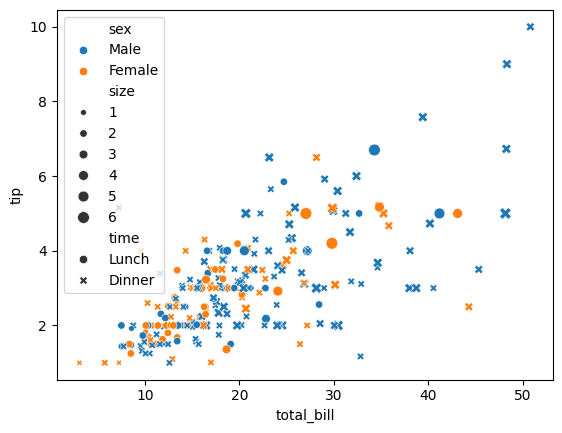

In [4]:
# Scatterplot - Axes level function

sns.scatterplot(data=tips,x='total_bill',y='tip',hue='sex',style='time',size='size')
# auto generates the legend.
# we can add additional details in the scatterplot and categorical variables.

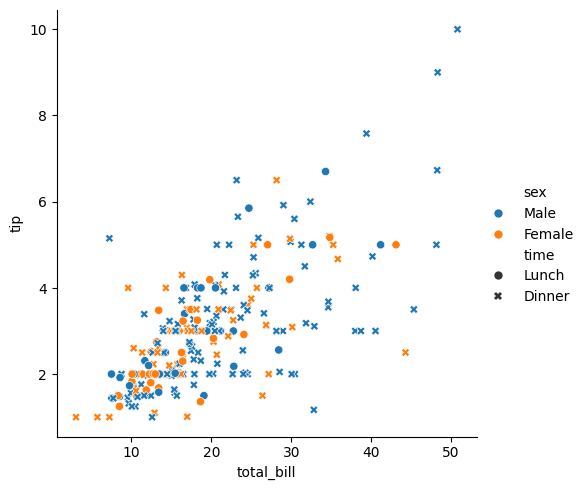

In [5]:
#Relplot -> a figure level function -> generally outputs square shaped image.

sns.relplot(data=tips, x='total_bill',y='tip',kind='scatter',hue='sex',style='time')

### Lineplot

Lineplot is just a connected scatterplot.
It is useful when we have to show continuity in our data.

- Specially useful to represent time variables.

In [6]:
# importing inbuilt dataset from plotly
gap = px.data.gapminder()
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [7]:
temp_df = gap[gap['country'] == 'India']

<Axes: xlabel='year', ylabel='lifeExp'>

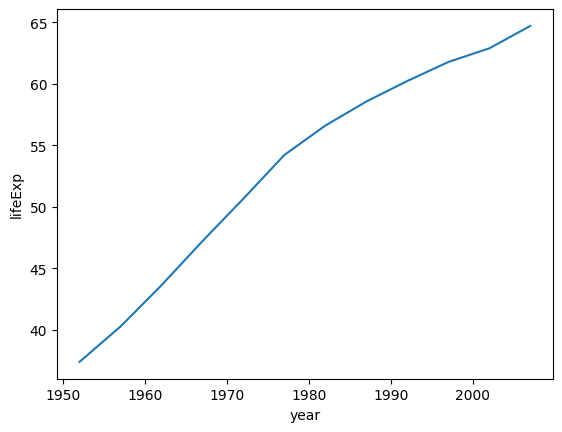

In [8]:
# axes level function

sns.lineplot(data=temp_df,x='year',y='lifeExp')

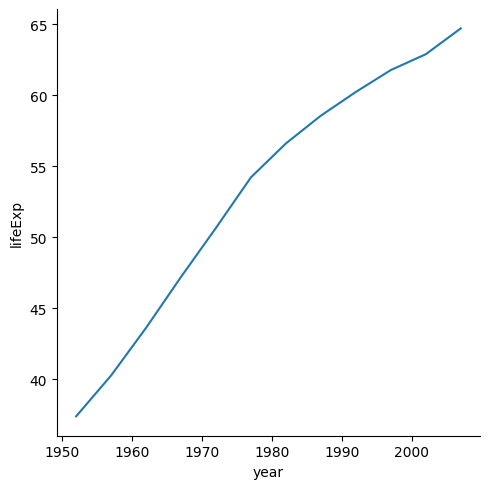

In [9]:
# plotting using figure level function - relplot

sns.relplot(data=temp_df,x='year',y='lifeExp',kind='line')

In [10]:
# hue / style

temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]

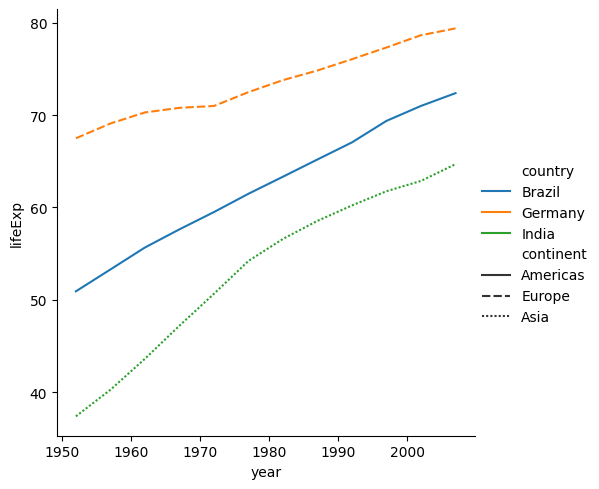

In [11]:
sns.relplot(kind='line', data=temp_df, x='year',y='lifeExp',hue='country',style='continent')

<Axes: xlabel='year', ylabel='lifeExp'>

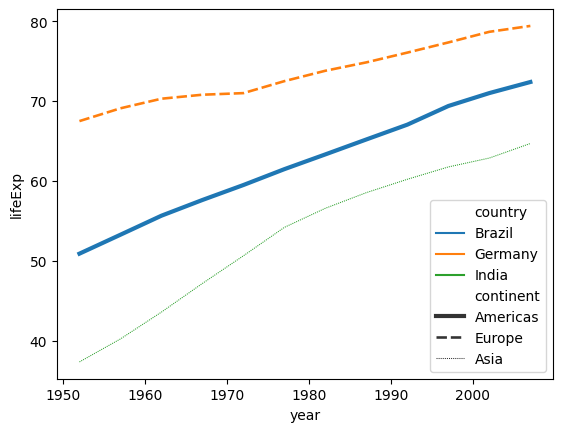

In [12]:
sns.lineplot(data=temp_df, x='year',y='lifeExp',hue='country',size='continent',style='continent')

### Facet Plot

A facet plot (also known as a small multiple or trellis plot) is a data visualization technique that splits a single chart into a grid of multiple subplots. Each subplot displays a specific subset of the data based on a categorical variable, making it easy to compare trends across different groups at a glance.

> ** Only works with figure level functions - means relplot() only, not sns.scatterplot()

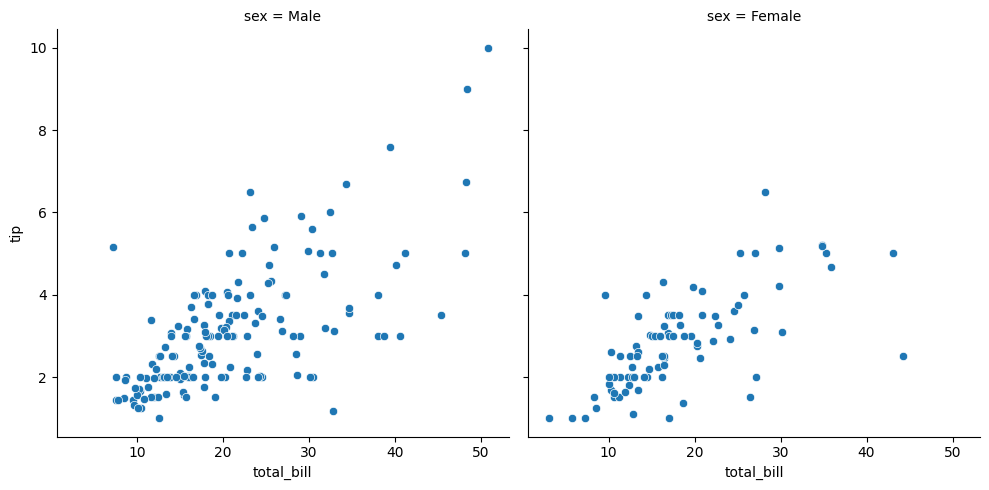

In [13]:
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='sex')

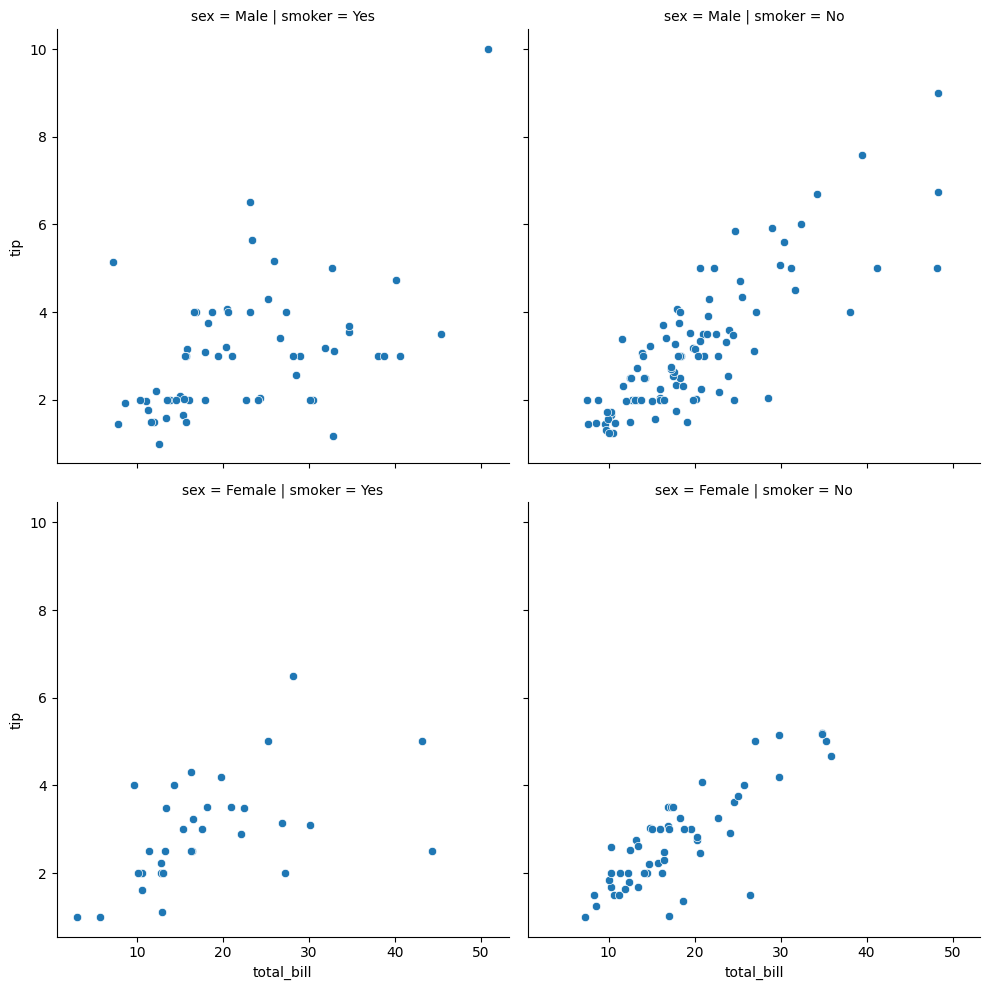

In [14]:
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='smoker',row='sex')

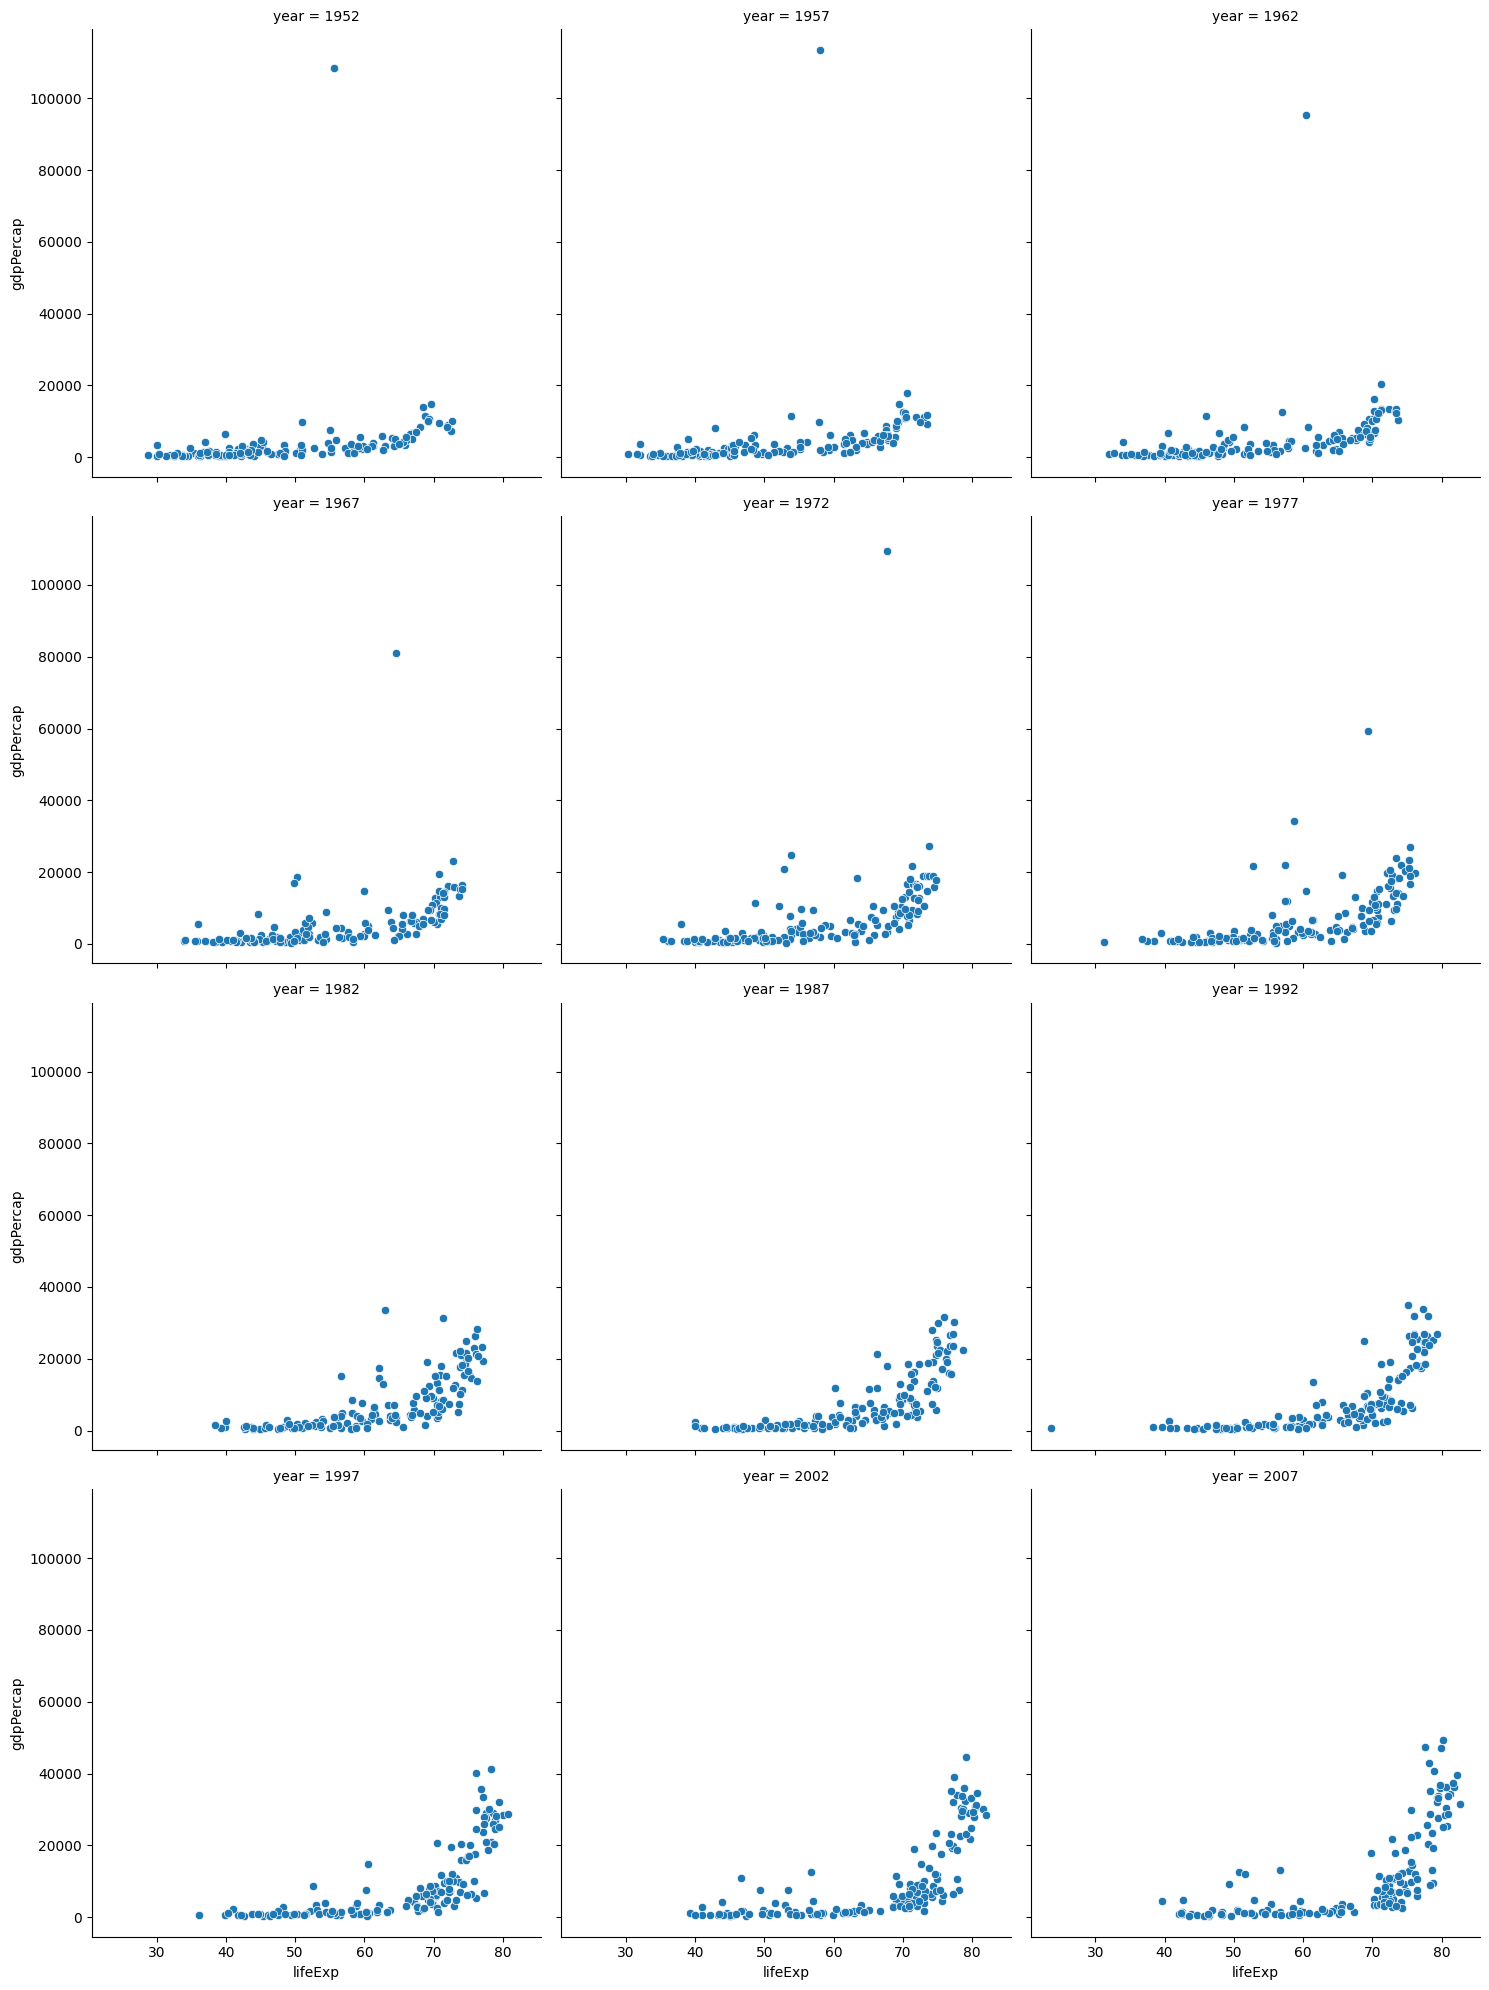

In [19]:
# col wrap

sns.relplot(data=gap,x='lifeExp',y='gdpPercap', kind='scatter',col='year', col_wrap=3)

## Distribution Plots

- used for univariate analysis
- used to find out the statistical distribution
- Range of the observation
- Central Tendency
- Is the data bimodal?
- Are there outliers?

Plots under distribution plot
- histplot
- kdeplot
- rugplot

**Axes level function** - histplot(), kdeplot(), rugplot()

**Figure level function** - displot()

### Histplot  (Histogram)

<Axes: xlabel='total_bill', ylabel='Count'>

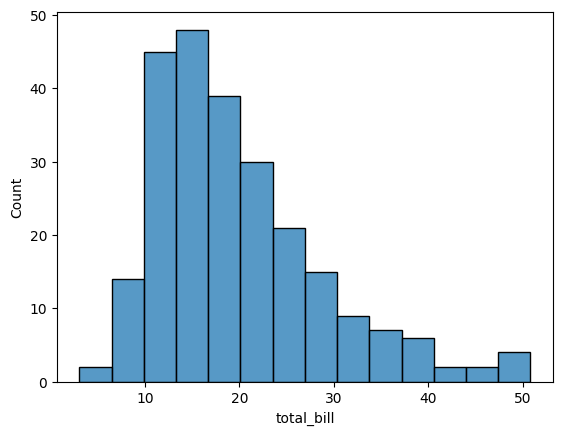

In [30]:
sns.histplot(data=tips,x='total_bill')

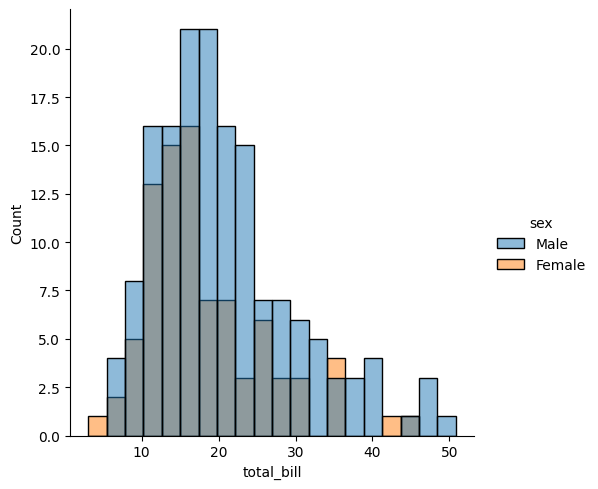

In [36]:
sns.displot(data=tips,x='total_bill',bins=20,hue='sex')

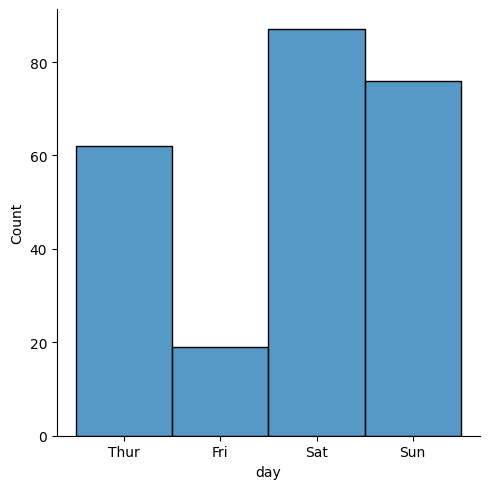

In [35]:
# plotting on a categorical column - it's more like count plot

sns.displot(data=tips,x='day',kind='hist')

In [38]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


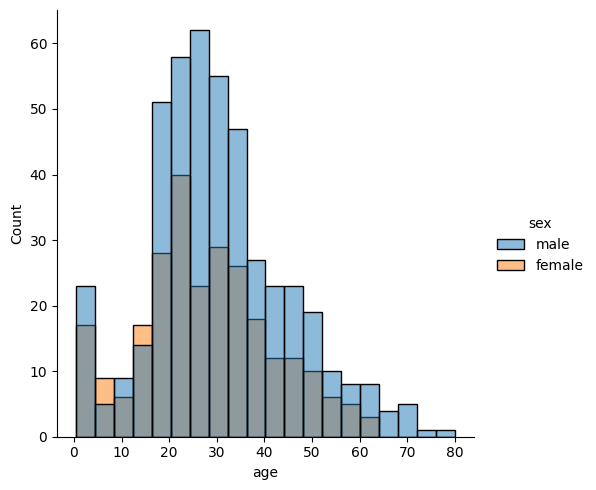

In [40]:
sns.displot(titanic,x='age',kind='hist',hue='sex')

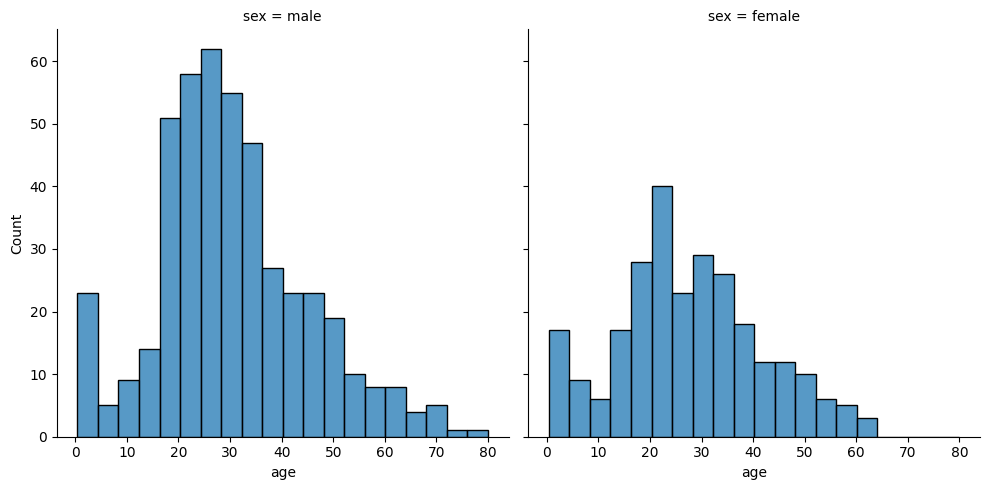

In [41]:
# facet plotting
sns.displot(titanic,x='age',kind='hist',col='sex')

### Kdeplot

Rather than using discrete bins, a kDE plot smooths the observations with a gaussian kernel, producing a contiuous density estimates.

<Axes: xlabel='total_bill', ylabel='Density'>

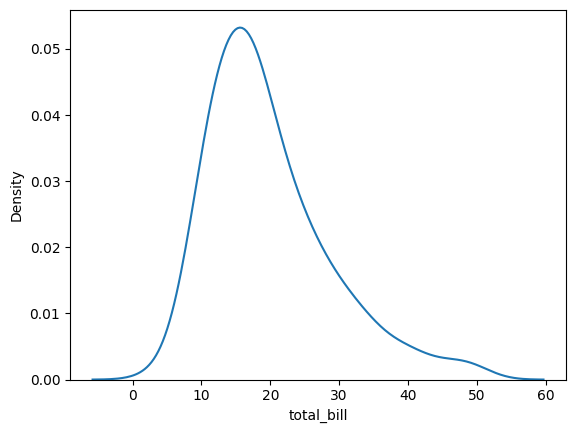

In [43]:
sns.kdeplot(data=tips,x='total_bill')